***Project Overview:***

**This project focuses on emotion detection from social media text using machine learning techniques. It involves data preprocessing, feature extraction using TF-IDF, handling class imbalance with SMOTE, and training multiple classifiers like Logistic Regression, Random Forest, and Naïve Bayes. The best-performing model is selected based on accuracy and saved for real-time predictions. The project also includes visualizations such as emotion distribution and confusion matrices to analyze model performance.**

**Step 1 : Import Required Libraries**

Import necessary libraries for data handling, visualization, machine learning, and model evaluation.



In [ ]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import os


Step 2 : Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 3:  Load the Dataset**

In [ ]:
file_path = "/content/drive/MyDrive/Social Media Emotion Dataset.csv"
df = pd.read_csv(file_path)

**Step 4 :  Preprocess Text Data**

Clean and preprocess text data by:

Converting to lowercase.

Removing URLs, mentions, hashtags, punctuation, and numbers.

Removing extra spaces.



In [ ]:

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'@\w+|#', '', text)  # Remove mentions and hashtags
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

**Step 5 :  Apply Text Preprocessing**

In [ ]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

**Step 6 : Visualize Emotion Distribution**

Create a bar plot to visualize the frequency of emotions in the dataset.



<ipython-input-32-f84d1c33f47d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['label'].value_counts().index, y=df['label'].value_counts().values, palette='viridis')


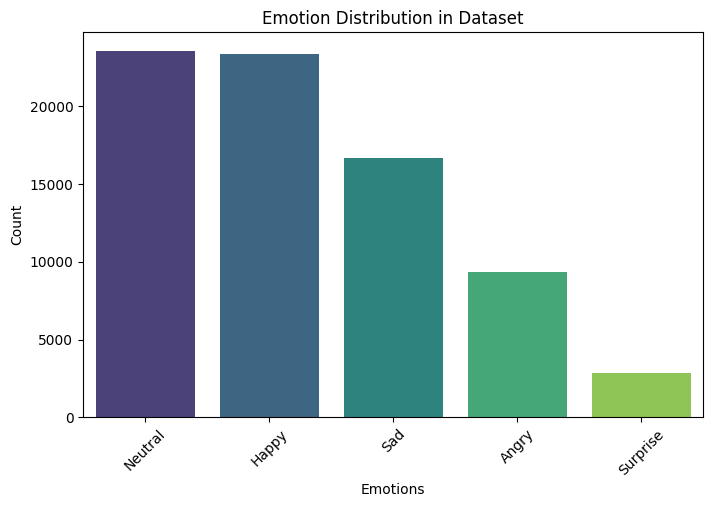

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['label'].value_counts().index, y=df['label'].value_counts().values, palette='viridis')
plt.xlabel("Emotions")
plt.ylabel("Count")
plt.title("Emotion Distribution in Dataset")
plt.xticks(rotation=45)
plt.show()

**Step 7 : Split Data into Training and Testing Sets**

 Split the dataset into training (80%) and testing (20%) sets.
  Ensures the label distribution remains balanced.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

**Step 8 :  Convert Text into TF-IDF Vectors**

Convert text into numerical form using TF-IDF.

In [ ]:
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

**Step 9 : Handle Class Imbalance using SMOTE**

Use SMOTE to generate synthetic samples for underrepresented classes.

Balancing the dataset improves model performance.

In [ ]:
smote = SMOTE(random_state=42)
X_train_tfidf, y_train = smote.fit_resample(X_train_tfidf, y_train)

**Step 10 : Hyperparameter Tuning for Logistic Regression**

 Tune C (regularization strength) and max_iter (iterations) using GridSearchCV.

In [ ]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(max_iter=200, random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)
best_logreg = grid_search.best_estimator_

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

**Step 11 : Train a Random Forest Classifier**



In [ ]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, max_features='sqrt', class_weight='balanced', random_state=42)
rf_model.fit(X_train_tfidf, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       random_state=42)

**Step 12. Train a Naïve Bayes Classifier**

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

**Step 13. Evaluate Models**

 Compute accuracy and classification reports for all models.

In [79]:
y_pred_logreg = logreg.predict(X_test_tfidf)
y_pred_rf = rf_model.predict(X_test_tfidf)
y_pred_nb = nb_model.predict(X_test_tfidf)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("\nLogistic Regression Accuracy:", logreg_accuracy)
print("Classification Report - Logistic Regression:\n", classification_report(y_test, y_pred_logreg))
print("\nRandom Forest Accuracy:", rf_accuracy)
print("Classification Report - Random Forest:\n", classification_report(y_test, y_pred_rf))
print("\nNaïve Bayes Accuracy:", nb_accuracy)
print("Classification Report - Naïve Bayes:\n", classification_report(y_test, y_pred_nb))


Logistic Regression Accuracy: 0.6324983520105472
Classification Report - Logistic Regression:
               precision    recall  f1-score   support

       Angry       0.64      0.71      0.67      1875
       Happy       0.72      0.67      0.70      4676
     Neutral       0.65      0.59      0.62      4717
         Sad       0.68      0.64      0.66      3334
    Surprise       0.14      0.33      0.20       568

    accuracy                           0.63     15170
   macro avg       0.57      0.59      0.57     15170
weighted avg       0.66      0.63      0.64     15170


Random Forest Accuracy: 0.5361898483849703
Classification Report - Random Forest:
               precision    recall  f1-score   support

       Angry       0.59      0.61      0.60      1875
       Happy       0.58      0.56      0.57      4676
     Neutral       0.57      0.64      0.60      4717
         Sad       0.60      0.36      0.45      3334
    Surprise       0.13      0.34      0.19       568

    a

**Step 14. Choose the Best Model**

Select the model with the highest accuracy.

In [ ]:
best_model, best_model_name = max(
    [(logreg, "logistic_regression_model.pkl", logreg_accuracy),
     (rf_model, "random_forest_model.pkl", rf_accuracy),
     (nb_model, "naive_bayes_model.pkl", nb_accuracy)],
    key=lambda x: x[2]
)[:2]

**Step 15. Save the Best Model Name**

In [ ]:
with open("best_model.txt", "w") as f:
    f.write(best_model_name)


**Step 16. Confusion Matrix Visualization**

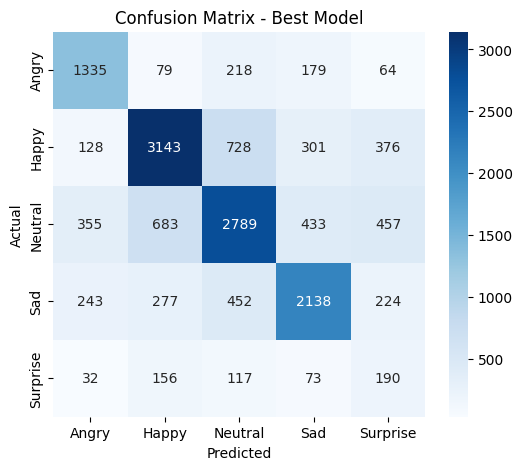

In [ ]:
labels = sorted(df['label'].unique())
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test_tfidf)), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")
plt.show()


**Step 17. Save Model and Vectorizer**

Save the best model and TF-IDF vectorizer for later use.

In [ ]:
joblib.dump(best_model, best_model_name)
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

**Step 18. Load the Best Model**

Load the best model dynamically with error handling

In [ ]:
def load_model():
    if not os.path.exists("best_model.txt"):
        raise FileNotFoundError("Model file not found. Train the model first.")
    with open("best_model.txt", "r") as f:
        best_model_name = f.read().strip()
    model = joblib.load(best_model_name)
    vectorizer = joblib.load("tfidf_vectorizer.pkl")
    return model, vectorizer

**Step 19. Function to predict emotion of new text with confidence handling**

In [ ]:
def predict_emotion(text):
    model, vectorizer = load_model()
    cleaned_text = preprocess_text(text)
    text_vector = vectorizer.transform([cleaned_text])
    prediction = model.predict(text_vector)[0]
    if hasattr(model, 'predict_proba'):
        confidence = model.predict_proba(text_vector).max()
    else:
        confidence = 1.0
    return prediction, confidence


**Step 20. Predict Emotion**

Predict emotion for a sample text.


In [ ]:
# Example usage
sample_text = "I'm feeling very happy today!"
prediction, confidence = predict_emotion(sample_text)
print(f"Predicted Emotion: {prediction} (Confidence: {confidence:.2f})")

Predicted Emotion: Happy (Confidence: 0.97)
